# Introduction to the Case Study
A successful fictional small high-tech manufacturer of health-focused products has the potential to become a larger player in the global smart device market.

Their Board believes that analyzing smart device fitness data could help unlock new growth opportunities for the company. They have asked the marketing analytics team to focus on analyzing smart device usage data in order to gain insight into and form hypotheses on how their users were doing on a daily basis. Then, using this information, they would like high-level recommendations for how these trends can inform new marketing strategies.

The audience and the primary stakeholder of the results of the analysis are: The Board and Marketing Analytics team.

The business task of this case study is:
> Based on smart device usage data, identify patterns and trends in user activities. From there, recommend marketing strategy directions for expansion.

I will use Python to complete this case study.
# Prepare the data
The data provided includes data on users' activity, intensity, calories, sleep, and weight for 2 months: from March 12 to April 11 and from April 12 to May 12, 2016.

*Sleep data is only recorded from April 12 to May 12, 2016.*

### Set up libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import the data
Let's import and set up our data

In [2]:
#Import the data
activity_34 = pd.read_csv("/kaggle/input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv")
weight_34 = pd.read_csv("/kaggle/input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv")
calories_34 = pd.read_csv("/kaggle/input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyCalories_merged.csv")
intensities_34 = pd.read_csv("/kaggle/input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyIntensities_merged.csv")
activity_45 = pd.read_csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
sleep_45 = pd.read_csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")
weight_45 = pd.read_csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/weightLogInfo_merged.csv")
calories_45 = pd.read_csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlyCalories_merged.csv")
intensities_45 = pd.read_csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlyIntensities_merged.csv")

Since the data is split into 2 time periods, I will append them together to have seamless data sets.

In [3]:
#Append data in two months into a seamless time dataframe
weight = pd.concat([weight_34, weight_45], ignore_index=True)
activity = pd.concat([activity_34, activity_45], ignore_index=True)
calories = pd.concat([calories_34, calories_45], ignore_index=True)
intensities = pd.concat([intensities_34, intensities_45], ignore_index=True)

#Let's take a look at our raw data
activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


In [4]:
sleep_45.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [5]:
weight.head()

,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,4/5/2016 11:59:59 PM,53.299999,117.506384,22.0,22.969999,True,1459900799000
1,1927972279,4/10/2016 6:33:26 PM,129.600006,285.719105,NaN,46.169998,False,1460313206000
2,2347167796,4/3/2016 11:59:59 PM,63.400002,139.773078,10.0,24.770000,True,1459727999000
3,2873212765,4/6/2016 11:59:59 PM,56.700001,125.002104,NaN,21.450001,True,1459987199000
4,2873212765,4/7/2016 11:59:59 PM,57.200001,126.104416,NaN,21.650000,True,1460073599000


In [6]:
calories.head()

,Id,ActivityHour,Calories
0,1503960366,3/12/2016 12:00:00 AM,48
1,1503960366,3/12/2016 1:00:00 AM,48
2,1503960366,3/12/2016 2:00:00 AM,48
3,1503960366,3/12/2016 3:00:00 AM,48
4,1503960366,3/12/2016 4:00:00 AM,48


In [7]:
intensities.head()

,Id,ActivityHour,TotalIntensity,AverageIntensity
0,1503960366,3/12/2016 12:00:00 AM,0,0.0
1,1503960366,3/12/2016 1:00:00 AM,0,0.0
2,1503960366,3/12/2016 2:00:00 AM,0,0.0
3,1503960366,3/12/2016 3:00:00 AM,0,0.0
4,1503960366,3/12/2016 4:00:00 AM,0,0.0


Note that activity, sleep, and weight data are recorded by day, while calorie burn and intensity data are recorded by hour.
# Process the data
### Normalization and date/time treatment
I will rename all date columns to `Date` and reformat them to the correct data type. Also truncate date data to day in data frames that record data by day, and split timestamp data in the ones recording data by hour into `Date` and `Time`.

In [8]:
#Column name normalization
activity.rename(columns={"ActivityDate":"Date", "ModeratelyActiveDistance":"FairlyActiveDistance"}, 
                inplace=True)
sleep_45.rename(columns={"SleepDay":"Date"}, inplace=True)

#Reformat date/time data type
activity["Date"] = pd.to_datetime(activity["Date"], format="%m/%d/%Y")
sleep_45["Date"] = pd.to_datetime(sleep_45["Date"], format="%m/%d/%Y %I:%M:%S %p")
weight["Date"] = pd.to_datetime(weight["Date"], format="%m/%d/%Y %I:%M:%S %p")
calories["ActivityHour"] = pd.to_datetime(calories["ActivityHour"], format="%m/%d/%Y %I:%M:%S %p")
intensities["ActivityHour"] = pd.to_datetime(intensities["ActivityHour"], format="%m/%d/%Y %I:%M:%S %p")

In [9]:
#Truncate date to day and split timestamp
weight["Date"] = weight["Date"].dt.floor("D")

calories["Date"] = calories["ActivityHour"].dt.date
calories["Time"] = calories["ActivityHour"].dt.time

intensities["Date"] = intensities["ActivityHour"].dt.date
intensities["Time"] = intensities["ActivityHour"].dt.time

### Remove duplicates
The logic is that each Id (user) in 1 day/hour has only 1 record. We will check and remove duplicate data, if any, according to this condition.

In [10]:
#Remove duplicate
weight.drop_duplicates(inplace=True)
sleep_45.drop_duplicates(inplace=True)
activity.drop_duplicates(inplace=True)
calories.drop_duplicates(inplace=True)
intensities.drop_duplicates(inplace=True)

#Check if there are any records with duplicate Id and date/hour
print(len(weight[["Id", "Date"]].value_counts().reset_index(name="apprearance_count")\
                                            .query('apprearance_count > 1')))
print(len(sleep_45[["Id", "Date"]].value_counts().reset_index(name="apprearance_count")\
                                            .query('apprearance_count > 1')))
print(len(activity[["Id", "Date"]].value_counts().reset_index(name="apprearance_count")\
                                            .query('apprearance_count > 1')))
print(len(calories[["Id", "ActivityHour"]].value_counts().reset_index(name="apprearance_count")\
                                            .query('apprearance_count > 1')))
print(len(intensities[["Id", "ActivityHour"]].value_counts().reset_index(name="apprearance_count")\
                                            .query('apprearance_count > 1')))

0
0
24
0
0


In [11]:
activity[["Id", "Date"]].value_counts().reset_index(name="apprearance_count")\
                                            .query('apprearance_count > 1')

,Id,Date,apprearance_count
0,4445114986,2016-04-12,2
1,4020332650,2016-04-12,2
2,8877689391,2016-04-12,2
3,1844505072,2016-04-12,2
4,2320127002,2016-04-12,2
5,2873212765,2016-04-12,2
6,4558609924,2016-04-12,2
7,5553957443,2016-04-12,2
8,8053475328,2016-04-12,2
9,3977333714,2016-04-12,2


So there are 24 IDs with Activity information recorded twice on April 12. We need to find a way to treat these duplicate rows.

Here, each ID has 2 records with the same date, so I will compare the value of these 2 records in each Id. To do that, we need to classify these 2 records, the record that appears first will be considered the original, the one that appears later will be the duplicate. Then compare the distribution of these 2 types of records.

In [12]:
#Assign the duplicate rows (including the original rows) in the Activity data frame to a new data frame
dup_down = activity.duplicated(subset=["Id", "Date"], keep="first")
dup_up = activity.duplicated(subset=["Id", "Date"], keep="last")
dup_act = activity[dup_down|dup_up].copy()

#Add a column to label which rows are considerd original and which are duplicates
dup_act["Label"] = np.where(dup_act.duplicated(subset=["Id", "Date"], keep="first"), "Duplicated", 
                            "Original")

#Sort the original and the duplicate consecutively 
dup_act = dup_act.sort_values(by=["Id", "Date"])
dup_act.head(6)

,Id,Date,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,FairlyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Label
18,1503960366,2016-04-12,224,0.14,0.14,0.0,0.00,0.00,0.13,0.0,0,0,9,32,50,Original
457,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Duplicated
37,1624580081,2016-04-12,6627,4.31,4.31,0.0,0.00,0.00,4.31,0.0,0,0,89,604,706,Original
488,1624580081,2016-04-12,8163,5.31,5.31,0.0,0.00,0.00,5.31,0.0,0,0,146,1294,1432,Duplicated
59,1844505072,2016-04-12,0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0,0,0,426,399,Original
549,1844505072,2016-04-12,6697,4.43,4.43,0.0,0.00,0.00,4.43,0.0,0,0,339,1101,2030,Duplicated


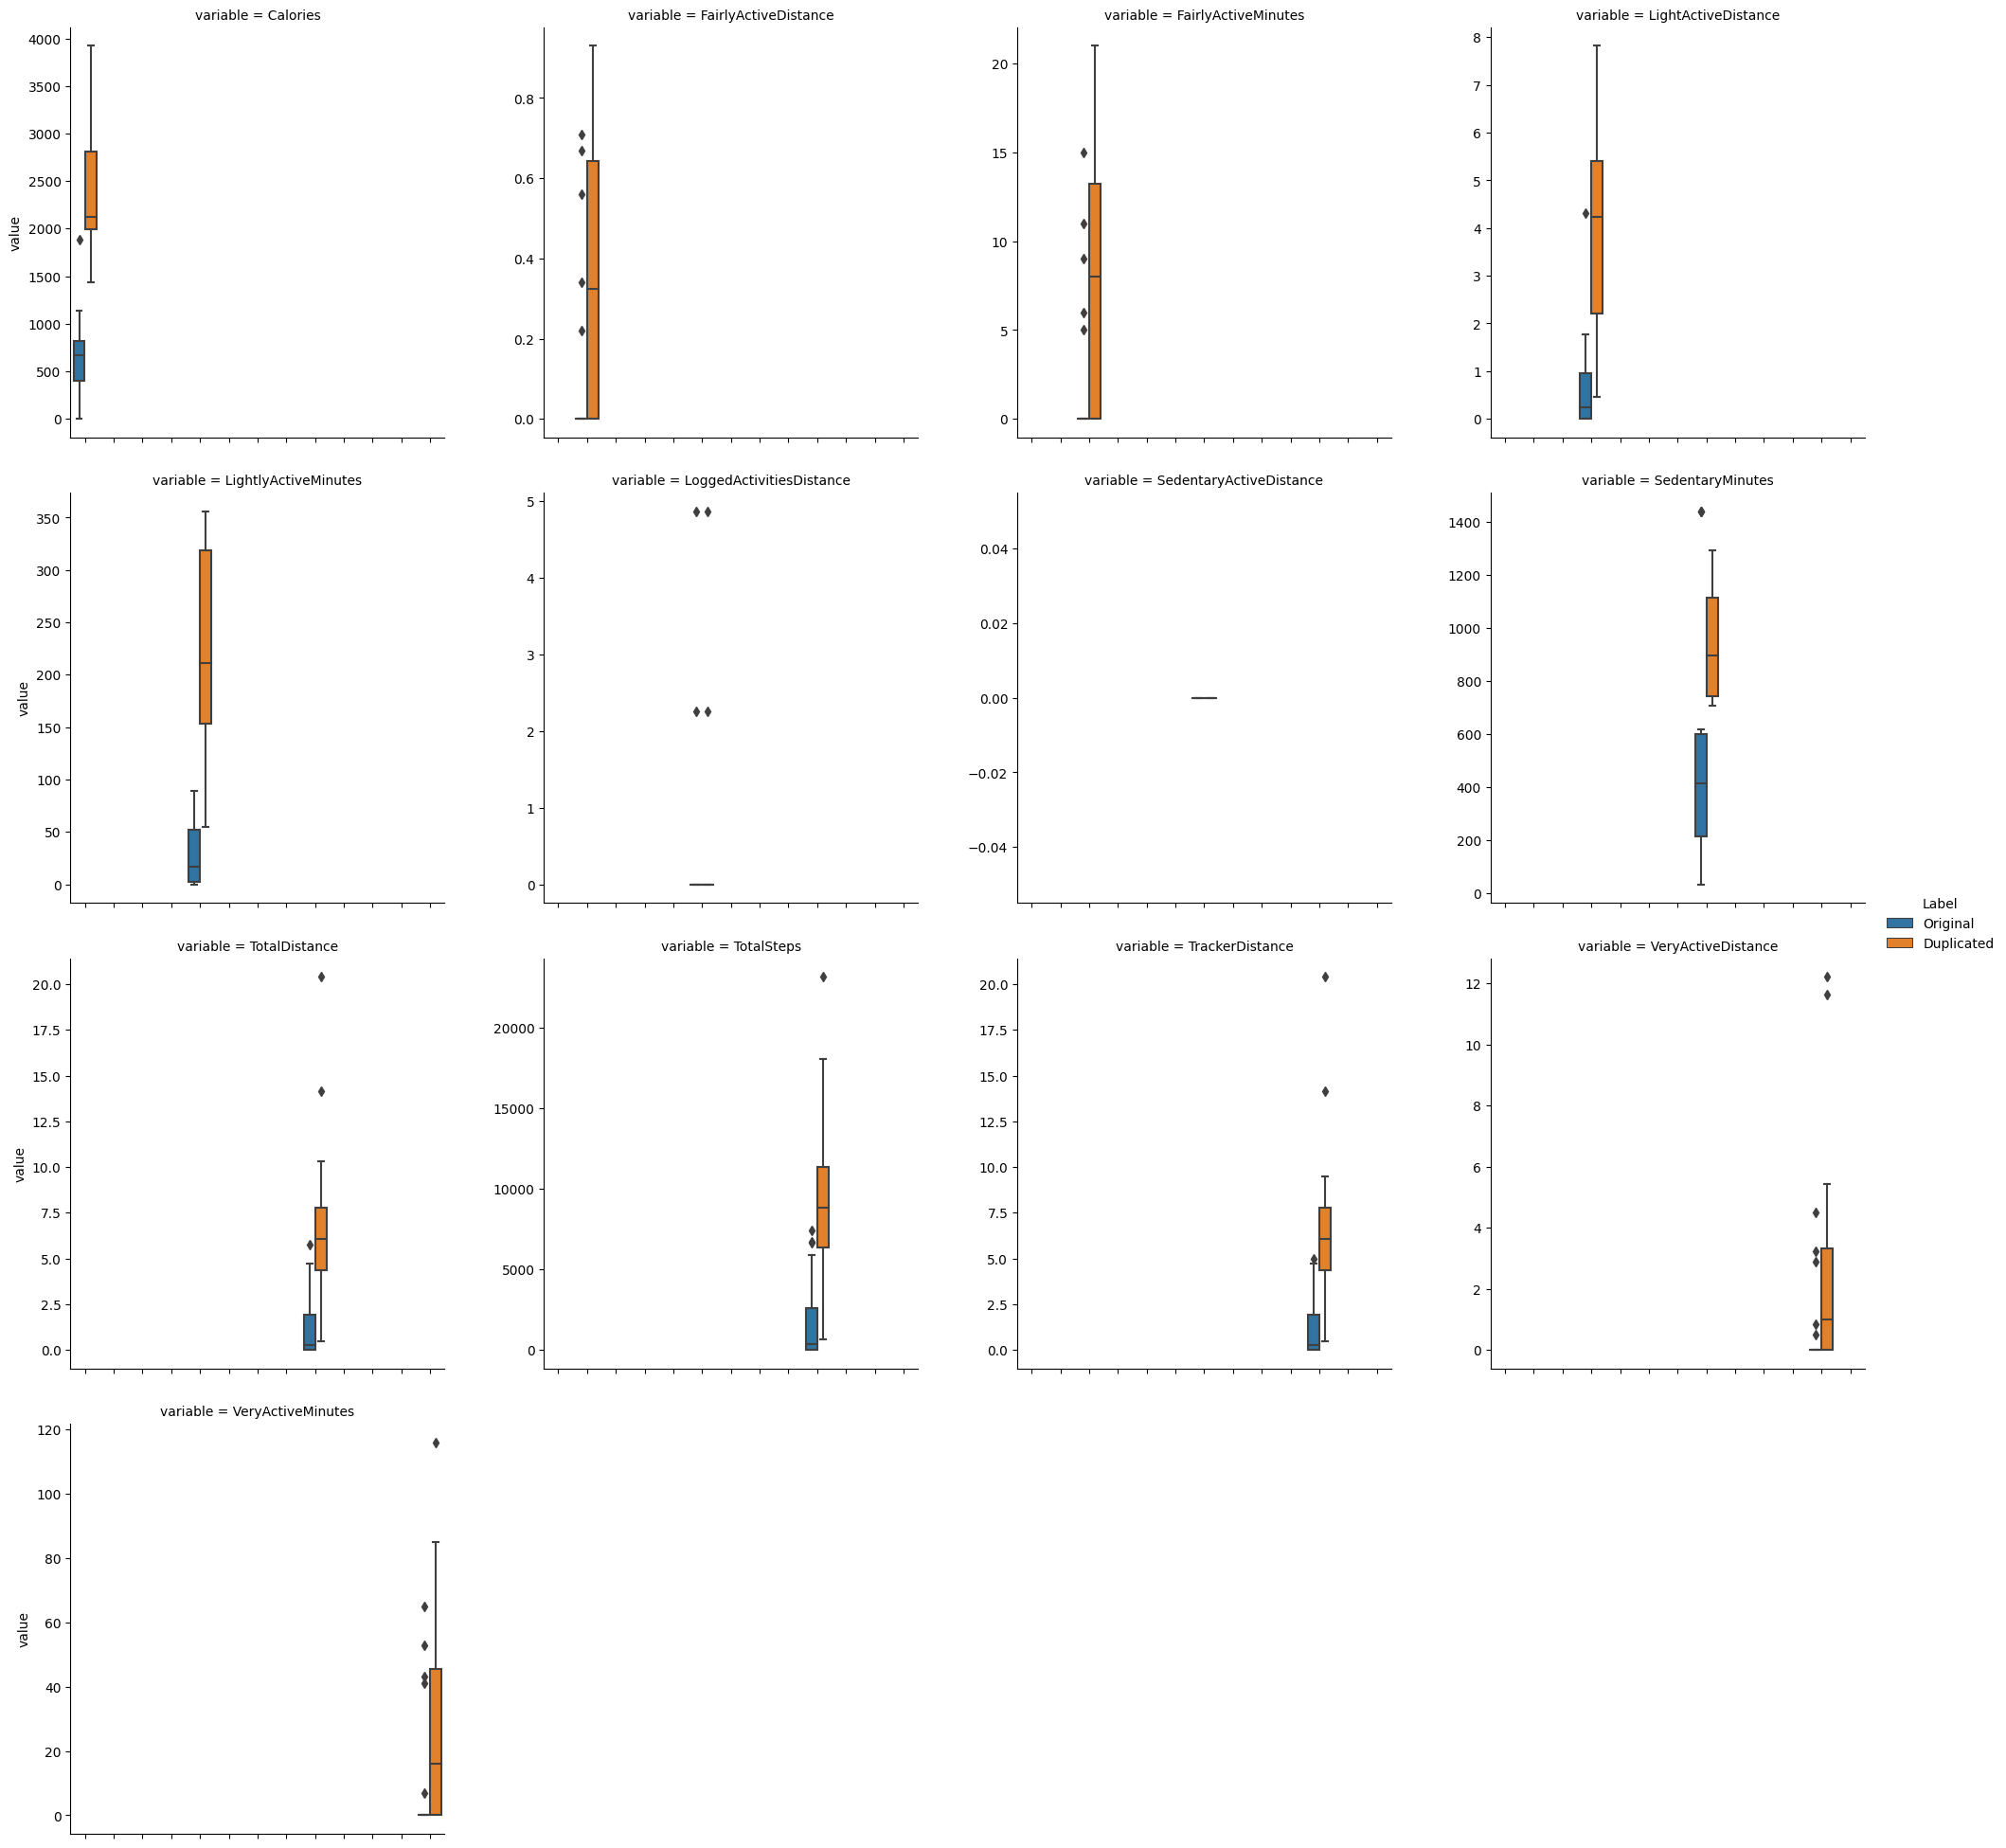

In [13]:
#Compare the distribution of duplicate and original value across several variables
dup_act_melt = pd.melt(dup_act, id_vars=["Id", "Date", "Label"], value_vars=dup_act
                       .columns.difference(["Id", "Date", "Label"]))
g = sns.catplot(data=dup_act_melt, 
            x="variable", 
            y="value", 
            kind="box", 
            hue="Label", 
            col="variable", 
            col_wrap=4, 
            sharey=False)
g.set(xticklabels=[])
g.set(xlabel=None)
plt.show()

We can see that in general, the values of the duplicate are much larger than the original. That means in the 2 records with duplicated `Id` and `Date` in the Activity data set, one generally has values much larger than the other.

So, I decided to group the two duplicate records and sum up the numeric values.

In [14]:
#Group all rows with duplicated Id and date values
#Then, calculate the sum of numeric columns in all duplicated rows
activity_new = activity.groupby(["Id", "Date"], as_index=False).sum()

# Analyze and Visualize the data

In [15]:
#Number of unique Id (user) in the data sets
print(activity["Id"].nunique(),
      sleep_45["Id"].nunique(),
      weight["Id"].nunique(),
      calories["Id"].nunique(),
      intensities["Id"].nunique())

35 24 13 35 35


A thing to note is that the `weight` dataset only records data from 13 users. 13 is not significant enough to make any suggestions or conclusions, compared to 24 from `sleep_45` and 35 from the other datasets. Furthermore, the `weight` dataset does not record information about the gender and height of the users, so it is difficult to analyze this weight data further. *So I will not conduct further analysis or explore the correlations of weight in this analysis.*

In [16]:
#Overview of statistics of variables in data sets
print(activity_new[activity_new
      .columns.difference(["Id", "Date", "TrackerDistance", "LoggedActivitiesDistance"])]\
      .describe())
print(sleep_45[sleep_45
      .columns.difference(["Id", "Date"])].describe())

          Calories  FairlyActiveDistance  FairlyActiveMinutes  \
count  1373.000000           1373.000000          1373.000000   
mean   2305.879825              0.547873            13.637291   
std     736.140154              0.873536            26.587846   
min       0.000000              0.000000             0.000000   
25%    1820.000000              0.000000             0.000000   
50%    2138.000000              0.200000             6.000000   
75%    2786.000000              0.790000            19.000000   
max    5517.000000              6.480000           660.000000   

       LightActiveDistance  LightlyActiveMinutes  SedentaryActiveDistance  \
count          1373.000000           1373.000000              1373.000000   
mean              3.249228            188.613256                 0.001733   
std               2.118545            113.429007                 0.007800   
min               0.000000              0.000000                 0.000000   
25%               1.730000   

**Some findings I have from above summary:**
* The average number of steps a user takes per day is 7,408. This is less than the 10,000 steps recommended by the Centers for Disease Control and Prevention (CDC) for adults;
* Most of the user activity time is light activity;
* The average sedentary time for users is 1010 minutes per day, which equates to almost 17 hours!
* On average, users sleep once for 7 hours per day.

Let's see the users' average activity time in a day.

In [17]:
#Determine the day of the week and the order of the days of the week
activity_new["WeekDay"] = activity_new["Date"].dt.strftime("%A")
week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
activity_new["WeekDay"] = pd.Categorical(activity_new["WeekDay"], categories=week_order, ordered=True)

#Convert Activity data from wide to long
activity_long = pd.melt(activity_new, id_vars="WeekDay", 
                        value_vars=["VeryActiveMinutes", "FairlyActiveMinutes", "LightlyActiveMinutes", 
                                    "SedentaryMinutes"], 
                        var_name="ActivityType", 
                        value_name="Minutes")

#Calculate the total percentage of time occupied by each type of activity in a day
activity_long["Percentage"] = activity_long.groupby("WeekDay", observed=False)["Minutes"]\
                                .transform(lambda x: x/x.sum()*100)
activity_pct_per_weekday = activity_long.groupby(["WeekDay", "ActivityType"], as_index=False, 
                                                 observed=False)["Percentage"].sum()
activity_pct_per_weekday = activity_pct_per_weekday.pivot(index="WeekDay", 
                                                          columns="ActivityType", 
                                                          values="Percentage")
activity_pct_per_weekday

ActivityType,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,VeryActiveMinutes
WeekDay,,,,
Monday,1.016805,14.789461,82.463419,1.730315
Tuesday,1.076581,15.192595,82.034753,1.696072
Wednesday,1.103873,15.593549,81.672064,1.630514
Thursday,1.050603,15.112748,82.256248,1.580401
Friday,1.266215,15.581924,81.665628,1.486234
Saturday,1.180097,16.659853,80.432661,1.727389
Sunday,1.044795,14.167098,83.267737,1.520369


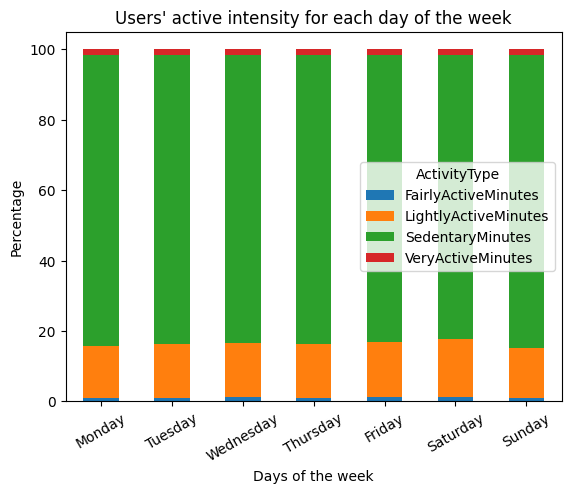

In [18]:
#Draw the plot
activity_pct_per_weekday.plot(kind="bar", stacked=True)
plt.title("Users' active intensity for each day of the week")
plt.xticks(rotation=30)
plt.xlabel("Days of the week")
plt.ylabel("Percentage")
plt.show()

We see that on any given day of the week, the average user's sedentary time accounts for more than **75%** of their day. This definitely needs to be reduced!

### Activity vs Sleep

Next, we will look at the correlation of sleep duration with other variables.

In [19]:
#Inner join activity and sleep
act_sleep = activity_new.merge(sleep_45, on=["Id", "Date"], how="inner")
act_sleep.head()

,Id,Date,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,FairlyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,WeekDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13386,8.64,8.64,0.0,1.88,0.55,6.19,0.0,25,13,337,760,2035,Tuesday,1,327,346
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Wednesday,2,384,407
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Friday,1,412,442
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Saturday,2,340,367
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728,Sunday,1,700,712


In [20]:
#Correlation between Total Minutes Asleep and all other activity variables
act_sleep_corr = round(
    act_sleep[act_sleep.columns.difference(["Id", "Date", "TrackerDistance", 
                                            "LoggedActivitiesDistance", "WeekDay"])].corr(), 2)
act_sleep_corr = act_sleep_corr.loc[act_sleep_corr.index != "TotalMinutesAsleep", 
                                    ["TotalMinutesAsleep"]]\
                                    .style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1)
act_sleep_corr

,TotalMinutesAsleep
Calories,-0.020000
FairlyActiveDistance,-0.250000
FairlyActiveMinutes,-0.250000
LightActiveDistance,-0.050000
LightlyActiveMinutes,0.030000
SedentaryActiveDistance,-0.040000
SedentaryMinutes,-0.520000
TotalDistance,-0.180000
TotalSleepRecords,0.170000
TotalSteps,-0.190000


Sleep duration is strongly correlated with time in bed and sedentary time:

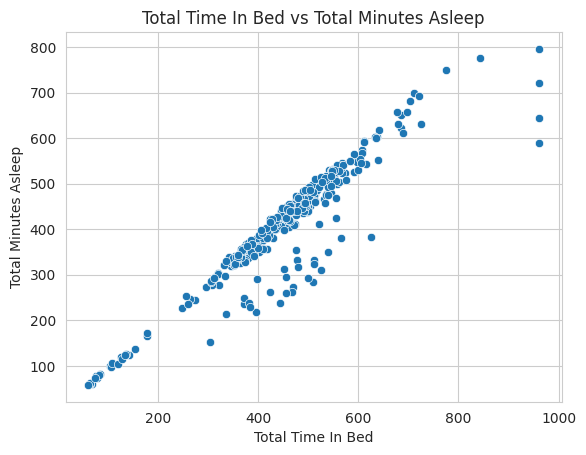

In [21]:
#Correlation between Total Time In Bed and Total Minute Asleep
sns.set_style("whitegrid")
sns.scatterplot(data=sleep_45, x="TotalTimeInBed", y="TotalMinutesAsleep")
plt.xlabel("Total Time In Bed")
plt.ylabel("Total Minutes Asleep")
plt.title("Total Time In Bed vs Total Minutes Asleep")
plt.show()

Sleep time has a very strong positive correlation with time spent in bed. **So if a user wants to increase their sleep time, Bellabeat might consider using bedtime notifications.**

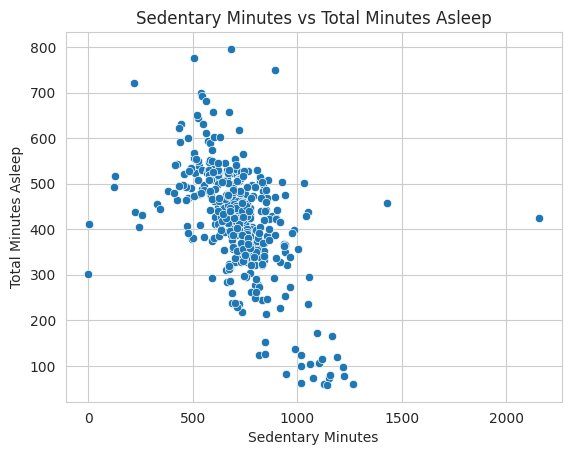

In [22]:
#Correlation between Sedentary Minutes and Total Minutes Asleep
sns.set_style("whitegrid")
sns.scatterplot(data=act_sleep, x="SedentaryMinutes", y="TotalMinutesAsleep")
plt.xlabel("Sedentary Minutes")
plt.ylabel("Total Minutes Asleep")
plt.title("Sedentary Minutes vs Total Minutes Asleep")
plt.show()

Conversely, sleep time is negatively correlated with sedentary time. **Bellabeat app can recommend users to reduce the sedentary time to have a better sleep duration.** However, we need more data to support this insight, because correlation between data doesn't mean causation.
 
### Intensity vs Calories
We will look at the average intensity and calories burned per day.

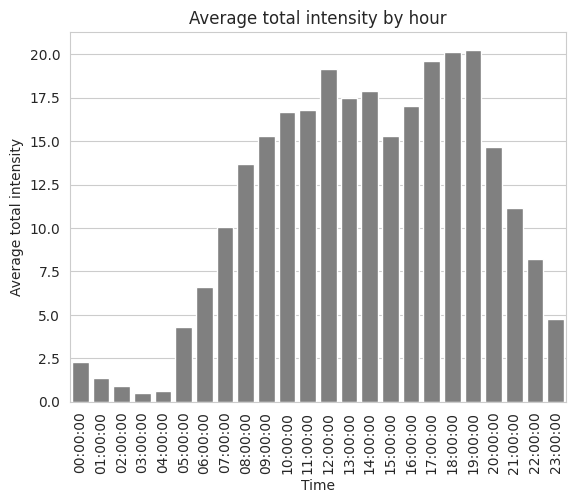

In [23]:
#Average intensities by hour
sns.set_style("whitegrid")
sns.barplot(data=intensities, 
            x="Time", 
            y="TotalIntensity", 
            estimator="mean", 
            errorbar=None, 
            color="grey")
plt.ylabel("Average total intensity")
plt.title("Average total intensity by hour")
plt.xticks(rotation=90)
plt.show()

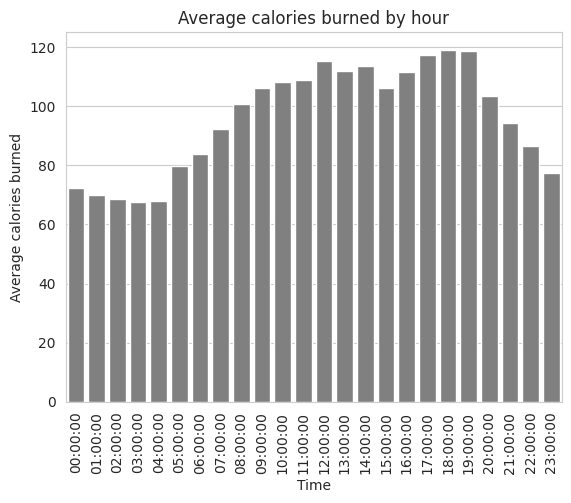

In [24]:
#Average calories burned by hour
sns.set_style("whitegrid")
sns.barplot(data=calories, 
            x="Time", 
            y="Calories", 
            estimator="mean", 
            errorbar=None, 
            color="grey")
plt.ylabel("Average calories burned")
plt.title("Average calories burned by hour")
plt.xticks(rotation=90)
plt.show()

The time with the highest intensity and the most calories burned is between 5pm and 7pm. I suppose this is the time after work and people start to work out and go to the gym.

**Bellabeat can send users motivational notifications to get moving right before this time.**

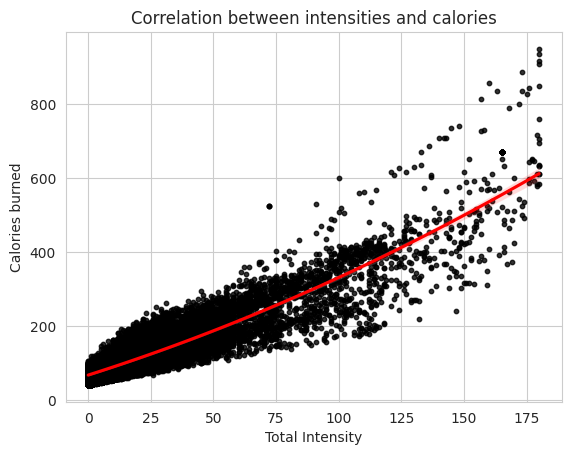

In [25]:
#Correlation between intensities and calories
intens_calo = intensities.merge(calories, on=["Id", "ActivityHour"], how="inner")

sns.set_style("whitegrid")
sns.regplot(data=intens_calo, 
            x="TotalIntensity", 
            y="Calories", 
            order=2, 
            color="black", 
            scatter_kws={"s": 10}, 
            line_kws={"color": "red"})
plt.xlabel("Total Intensity")
plt.ylabel("Calories burned")
plt.title("Correlation between intensities and calories")
plt.show()

Yes, definitely. Calorie burn has a very strong positive correlation with intensity. The greater the intensity of the activity, the more calories we burn.
# Conclusion and Recommendation
In conclusion, I have come up with the following findings and hypotheses about smart device users:
1. On average, users are taking fewer steps per day than recommended.
2. Most of the time during the day of users is sedentary, up to an average of 17 hours per day.
3. Sedentary time is negatively correlated with sleep time.
4. Sleep time is strongly positively correlated with time spent in bed.
5. The period with the highest intensity is from 5pm to 7pm, probably after work.
6. Intensity is strongly positively correlated with calories burned, so 5pm to 7pm is also the period with the highest calorie burn.

**So, I have the following recommendations for Bellabeat's upcoming experiment and marketing strategy:**
> Concept: Define the communication message as a smart product that accompanies health improvement and a balanced life. The target audience is office workers and health-conscious people.

Develop notification and reminder features based on user data and needs, for example:
* Remind users to walk or run more, reduce sedentary time to be healthier and lower health risks;
* If users want to improve sleep quality, inform users to set notifications for bedtime;
* If users want to lose weight, create after-work notifications to motivate users to work out and increase intensity.

### Epilogue
This notebook is the entire process that I went through to complete the Bellabeat smart devices case study. Although there may be biases or confusions that I am not aware of, I would appreciate your feedback if there are any limitations you find. Thank you for your interest in my analysis.